### Imports

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Data Preprocessing

In [2]:
data=pd.read_excel('/kaggle/input/food-delivery-time-prediction-case-study/Food Delivery Time Prediction Case Study.xlsx')

In [3]:
data.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [4]:
data.shape

(45593, 11)

In [5]:
data.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)'],
      dtype='object')

In [6]:
data['ID'].value_counts()

ID
7000    4
6000    4
9000    4
700     4
900     3
       ..
2947    1
4102    1
C3F1    1
5DB7    1
5FB2    1
Name: count, Length: 45355, dtype: int64

In [7]:
data.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Type_of_order                  0
Type_of_vehicle                0
Time_taken(min)                0
dtype: int64

In [8]:
data.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


### Label Encoding 

In [10]:
le=LabelEncoder()
data['Delivery_person_ID']=le.fit_transform(data['Delivery_person_ID'])
data['Type_of_order']=le.fit_transform(data['Type_of_order'])
data['Type_of_vehicle']=le.fit_transform(data['Type_of_vehicle'])

### EDA

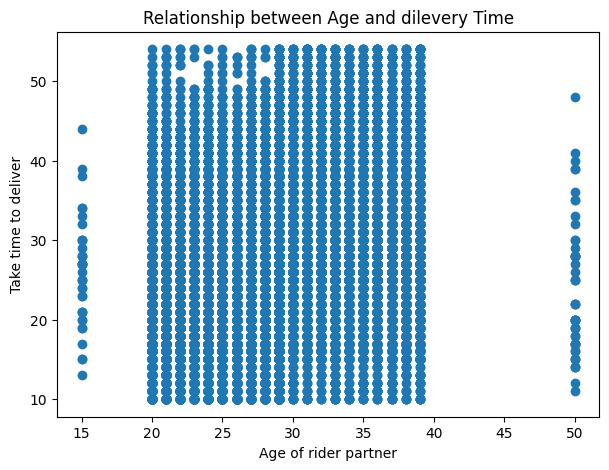

In [11]:
plt.figure(figsize=(7,5))
x=data['Delivery_person_Age']
y=data['Time_taken(min)']
plt.scatter(x,y)
plt.xlabel('Age of rider partner')
plt.ylabel('Take time to deliver')
plt.title('Relationship between Age and dilevery Time')
plt.show()

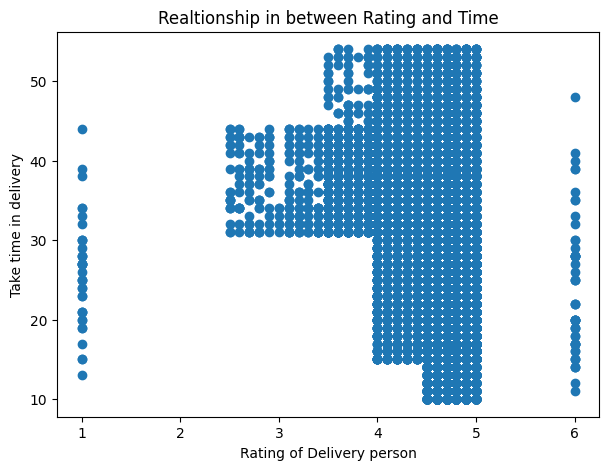

In [12]:
x=data['Delivery_person_Ratings']
y=data['Time_taken(min)']
plt.figure(figsize=(7,5))
plt.scatter(x,y)
plt.xlabel('Rating of Delivery person')
plt.ylabel('Take time in delivery')
plt.title('Realtionship in between Rating and Time')
plt.show()

In [13]:
data['Delivery_person_Age'].describe()

count    45593.000000
mean        29.544075
std          5.696793
min         15.000000
25%         25.000000
50%         29.000000
75%         34.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

In [14]:
data[data['Delivery_person_Age']<18].shape

(38, 11)

In [15]:
data[data['Delivery_person_Age']>=18].shape

(45555, 11)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


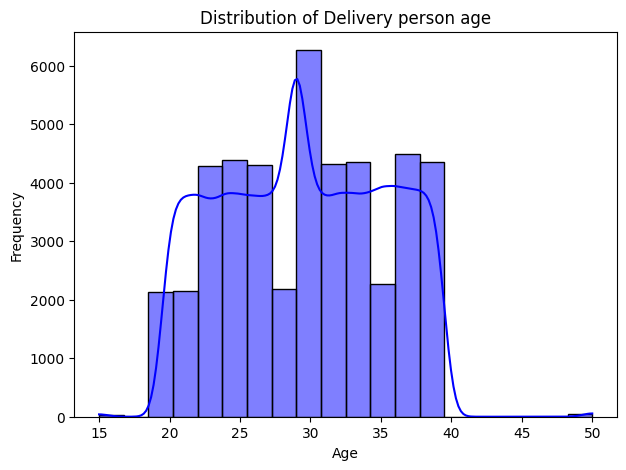

In [16]:
plt.figure(figsize=(7,5))
sns.histplot(data['Delivery_person_Age'],kde=True,bins=20,color='blue')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery person age')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


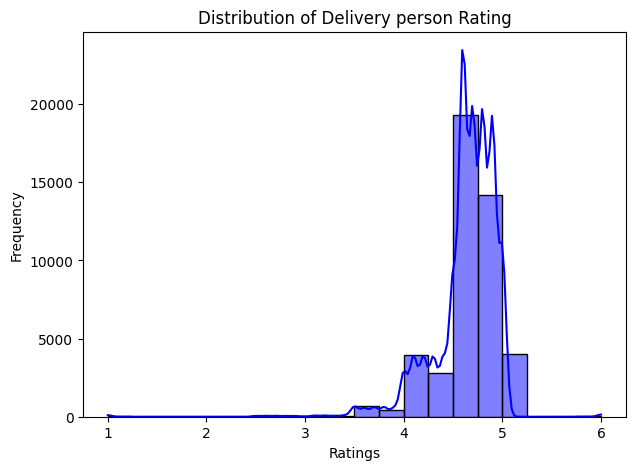

In [17]:
plt.figure(figsize=(7,5))
sns.histplot(data['Delivery_person_Ratings'],kde=True,bins=20,color='blue')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery person Rating')
plt.show()

In [18]:
data[data['Delivery_person_Ratings']>=2.5].shape

(45555, 11)

In [19]:
def classify_ratings_group(rating):
    if 2.5<= rating <4:
        return 0.0
    elif 4<= rating < 4.5:
        return 1.0
    elif 4.5<= rating <5:
        return 2.0
    else:
        return 3.0

data['rating_group']=data['Delivery_person_Ratings'].apply(classify_ratings_group)

In [20]:
data.groupby(by='rating_group')['Time_taken(min)'].mean()

rating_group
0.0    37.142965
1.0    34.647946
2.0    24.288842
3.0    25.515048
Name: Time_taken(min), dtype: float64

In [21]:
def classify_ratings_group(rating):
    if 2.5<= rating <4:
        return 0.0
    elif 4<= rating < 4.5:
        return 1.0
    elif 4.5<= rating <5:
        return 2.0
    else:
        return 3.0

data['Age_group']=data['Delivery_person_Age'].apply(classify_ratings_group)

In [22]:
data.groupby(by='Age_group')['Time_taken(min)'].mean()

Age_group
3.0    26.294607
Name: Time_taken(min), dtype: float64

In [23]:
data.groupby(by='rating_group')['Time_taken(min)'].mean()

rating_group
0.0    37.142965
1.0    34.647946
2.0    24.288842
3.0    25.515048
Name: Time_taken(min), dtype: float64

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

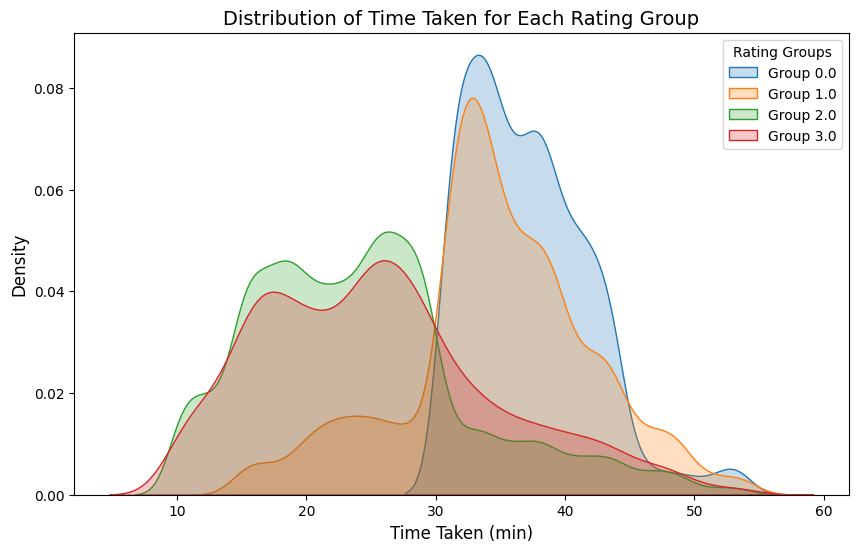

In [24]:
rating_groups = data.groupby('rating_group')['Time_taken(min)']

plt.figure(figsize=(10, 6))
for group, values in rating_groups:
    sns.kdeplot(values, label=f'Group {group}', fill=True)

plt.title('Distribution of Time Taken for Each Rating Group', fontsize=14)
plt.xlabel('Time Taken (min)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Rating Groups')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


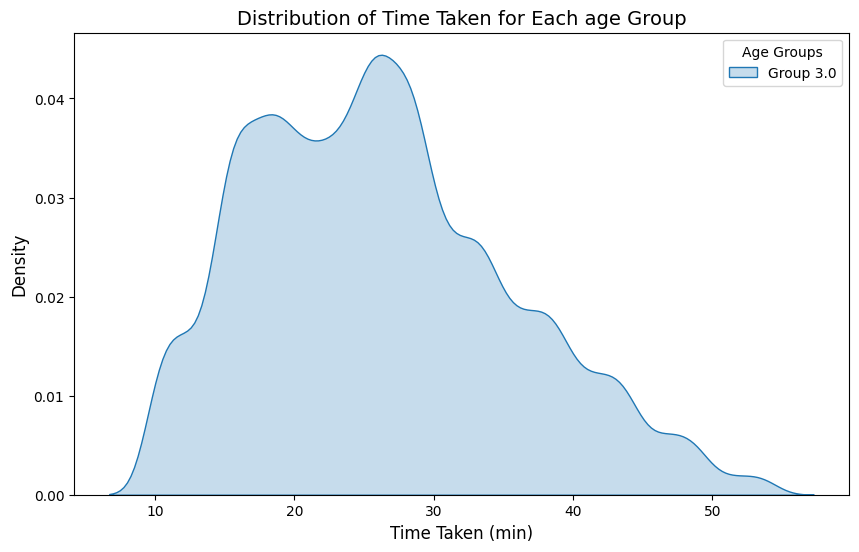

In [25]:
age_groups = data.groupby('Age_group')['Time_taken(min)']

plt.figure(figsize=(10, 6))
for group, values in age_groups:
    sns.kdeplot(values, label=f'Group {group}', fill=True)

plt.title('Distribution of Time Taken for Each age Group', fontsize=14)
plt.xlabel('Time Taken (min)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Age Groups')
plt.show()

In [26]:
data.drop('ID',axis=1,inplace=True)
data.drop('Delivery_person_ID',axis=1,inplace=True)

In [27]:
X=data.drop('Time_taken(min)',axis=1)
y=data['Time_taken(min)']

### Model Training

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [30]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

### Predictions & Metrics

In [31]:
# Predictions
y_pred = lr.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 0.1952
MAE: 6.57
RMSE: 8.40


### Visualization: Actual vs Predicted

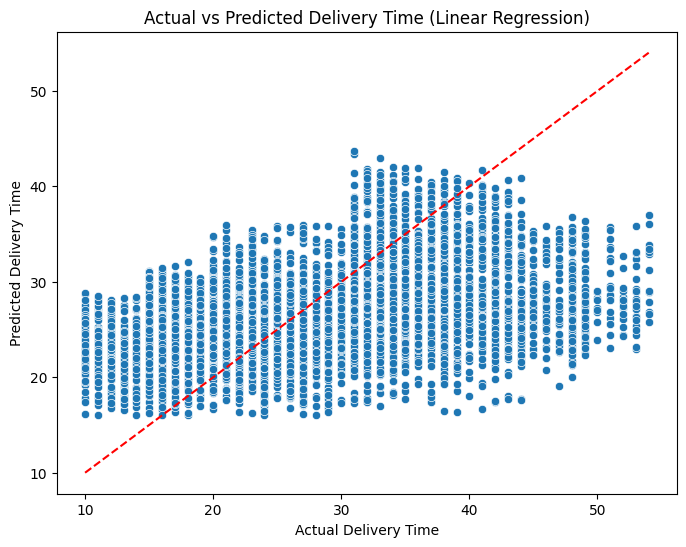

In [32]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time (Linear Regression)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

### Residuals Plot

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


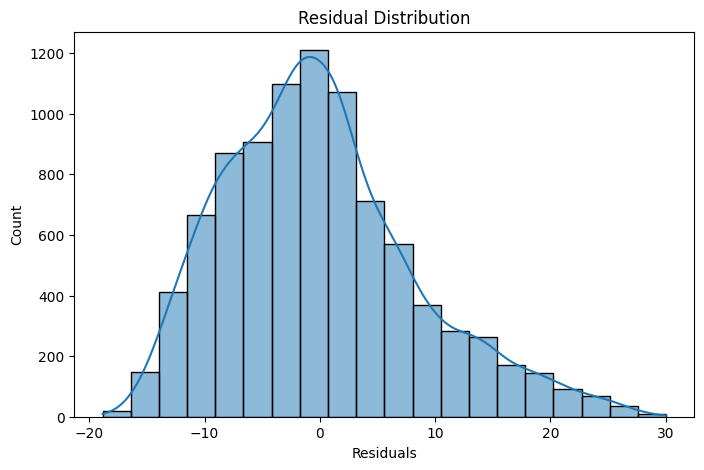

In [33]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=20, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()